# Symrise Data Engineering Challenge — Exploratory Analysis

This notebook is a **presentation layer**, not a second implementation: every
query below is read directly from [`sql/queries.sql`](../sql/queries.sql) /
[`sql/analysis.sql`](../sql/analysis.sql), and every chart is generated by
calling the same [`src/visualize.py`](../src/visualize.py) used by the CLI
(`python -m src.visualize`). Nothing here is redefined or hand-copied — if a
query or chart changes in those files, re-running this notebook picks up the
change automatically.

Run [`python -m src.pipeline`](../src/pipeline.py) first so `symrise_data.db`
reflects the current data. See [`README.md`](../README.md) for the full setup,
[`output/data_quality_report.md`](../output/data_quality_report.md) for data
quality findings, and [`output/business_answers.md`](../output/business_answers.md)
for the narrative answer to each business question below.

In [1]:
import sqlite3
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path) -> Path:
    """Works whether Jupyter's cwd is the repo root or notebooks/."""
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'pipeline.py').exists():
            return candidate
    raise FileNotFoundError("Could not locate project root (looked for src/pipeline.py)")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))

DB_PATH = PROJECT_ROOT / 'symrise_data.db'
conn = sqlite3.connect(DB_PATH)
print(f"Connected to {DB_PATH}")

Connected to C:\Users\User\Desktop\Personal\Proyectos\Symrise\Sergio-Diaz-symrise-challenge\symrise_data.db


In [2]:
def read_statements(sql_path: Path) -> list[str]:
    """Split a .sql file into individually executable statements.

    Comment-only lines are stripped before splitting on ';' - a naive split
    on the raw text breaks when a comment contains a semicolon as
    punctuation (this file has one: "...is the answer; the full ranking...").
    """
    text = sql_path.read_text(encoding='utf-8')
    code_lines = [line for line in text.splitlines() if not line.strip().startswith('--')]
    return [s.strip() for s in ' '.join(code_lines).split(';') if s.strip()]


def run(sql_path: Path, index: int) -> pd.DataFrame:
    statement = read_statements(sql_path)[index]
    print(statement)
    return pd.read_sql(statement, conn)

## Business questions (`sql/queries.sql`)

### Q1. Top 5 best-selling product categories by revenue

In [3]:
QUERIES = PROJECT_ROOT / 'sql' / 'queries.sql'
run(QUERIES, 0)

SELECT     COALESCE(p.category, 'Unknown/Unmatched Product') AS category,     SUM(s.total_amount_usd) AS total_revenue,     COUNT(*) AS num_transactions FROM sales s LEFT JOIN products p ON s.product_id = p.product_id GROUP BY category ORDER BY total_revenue DESC LIMIT 5


,category,total_revenue,num_transactions
0,Flavor,298425.0,47
1,Fragrance,191096.0,42
2,Unknown/Unmatched Product,5400.0,1


### Q2. Region with the highest average customer satisfaction score

In [4]:
run(QUERIES, 1)

SELECT     customer_region.region,     ROUND(AVG(f.overall_satisfaction), 3) AS avg_overall_satisfaction,     COUNT(*) AS num_feedback FROM feedback f JOIN (     SELECT DISTINCT customer_id, product_id, region FROM sales ) AS customer_region     ON f.customer_id = customer_region.customer_id    AND f.product_id = customer_region.product_id GROUP BY customer_region.region ORDER BY avg_overall_satisfaction DESC


,region,avg_overall_satisfaction,num_feedback
0,North America,4.650,12
1,EMEA,4.376,21
2,LATAM,4.125,8
3,APAC,4.071,14


### Q3. Product complexity (num_ingredients) vs. customer satisfaction

SQLite has no `CORR()` aggregate, so the Pearson coefficient is computed
here in pandas on the raw `(num_ingredients, overall_satisfaction)` pairs
returned by query 3a; query 3b gives the same relationship as a SQL-only
grouped average, for an eyeball-able sanity check.

In [5]:
pairs = run(QUERIES, 2)  # 3a: raw pairs
pairs.corr().loc['num_ingredients', 'overall_satisfaction']

SELECT     p.num_ingredients,     f.overall_satisfaction FROM feedback f JOIN products p ON f.product_id = p.product_id WHERE p.num_ingredients IS NOT NULL


np.float64(-0.26432813175665854)

In [6]:
run(QUERIES, 3)  # 3b: grouped average

SELECT     p.num_ingredients,     ROUND(AVG(f.overall_satisfaction), 3) AS avg_overall_satisfaction,     COUNT(*) AS num_feedback FROM feedback f JOIN products p ON f.product_id = p.product_id WHERE p.num_ingredients IS NOT NULL GROUP BY p.num_ingredients ORDER BY p.num_ingredients


,num_ingredients,avg_overall_satisfaction,num_feedback
0,5.0,4.700,3
1,6.0,4.600,4
2,7.0,4.200,5
3,8.0,4.429,7
4,9.0,4.150,4
5,10.0,4.700,3
6,11.0,4.033,3
7,12.0,4.333,6
8,13.0,4.867,3
9,14.0,4.375,4


### Q4. Products with declining sales trends (last 2 quarters)

In [7]:
run(QUERIES, 4)

WITH quarterly_sales AS (     SELECT         product_id,         CAST(strftime('%Y', transaction_date) AS INTEGER) * 10             + ((CAST(strftime('%m', transaction_date) AS INTEGER) - 1) / 3 + 1) AS year_quarter,         SUM(total_amount_usd) AS revenue     FROM sales     WHERE product_id IS NOT NULL     GROUP BY product_id, year_quarter ), ranked AS (     SELECT         product_id,         year_quarter,         revenue,         ROW_NUMBER() OVER (PARTITION BY product_id ORDER BY year_quarter DESC) AS quarter_rank     FROM quarterly_sales ) SELECT     curr.product_id,     p.product_name,     prev.year_quarter AS previous_quarter,     prev.revenue AS previous_quarter_revenue,     curr.year_quarter AS latest_quarter,     curr.revenue AS latest_quarter_revenue,     ROUND((curr.revenue - prev.revenue) * 100.0 / prev.revenue, 1) AS pct_change FROM ranked curr JOIN ranked prev     ON curr.product_id = prev.product_id    AND curr.quarter_rank = 1    AND prev.quarter_rank = 2 LEFT JOIN pro

,product_id,product_name,previous_quarter,previous_quarter_revenue,latest_quarter,latest_quarter_revenue,pct_change
0,P007,Green Tea Essence,20241,6600.0,20243,3300.0,-50.0
1,P008,Rose Garden,20241,11970.0,20243,5985.0,-50.0
2,P009,Mango Tango,20241,12395.0,20243,6197.5,-50.0
3,P014,Peach Nectar,20241,10980.0,20243,5490.0,-50.0
4,P010,Sandalwood Mystic,20241,8190.0,20243,4192.5,-48.8
5,P012,Lavender Fields,20242,5637.5,20243,5535.0,-1.8


### Q5. Profit margin per product category (Revenue − Ingredient Cost)

In [8]:
run(QUERIES, 5)

SELECT     p.category,     SUM(s.total_amount_usd) AS total_revenue,     SUM(s.quantity_kg * COALESCE(i.cost_per_kg_usd, 0)) AS total_ingredient_cost_estimate,     SUM(s.total_amount_usd) - SUM(s.quantity_kg * COALESCE(i.cost_per_kg_usd, 0)) AS profit_margin_usd,     ROUND(         (SUM(s.total_amount_usd) - SUM(s.quantity_kg * COALESCE(i.cost_per_kg_usd, 0))) * 100.0         / SUM(s.total_amount_usd), 1     ) AS profit_margin_pct FROM sales s JOIN products p ON s.product_id = p.product_id LEFT JOIN ingredients i ON p.primary_ingredient = i.ingredient_name GROUP BY p.category ORDER BY profit_margin_usd DESC


,category,total_revenue,total_ingredient_cost_estimate,profit_margin_usd,profit_margin_pct
0,Flavor,298425.0,94946.500,203478.500,68.2
1,Fragrance,191096.0,95842.875,95253.125,49.8


## Exploratory analysis (`sql/analysis.sql`)

Ten additional queries beyond the 5 business questions - monthly revenue
trend, status/channel/region breakdowns, top products, reorder rate,
ingredient cost spread, customer concentration, unsold products, and rating
sub-components. Full commentary for each lives in the `.sql` file itself.

In [9]:
ANALYSIS = PROJECT_ROOT / 'sql' / 'analysis.sql'
statements = read_statements(ANALYSIS)
print(f"{len(statements)} analysis queries")

10 analysis queries


In [10]:
for i, statement in enumerate(statements):
    print(f"--- analysis.sql, query {i + 1}/{len(statements)} ---")
    display(pd.read_sql(statement, conn))

--- analysis.sql, query 1/10 ---


,year_month,revenue,num_transactions
0,2024-01,50006.0,10
1,2024-02,66877.5,12
2,2024-03,69262.5,12
3,2024-04,59637.5,11
4,2024-05,74685.0,13
5,2024-06,63235.0,12
6,2024-07,66080.0,12
7,2024-08,45137.5,8


--- analysis.sql, query 2/10 ---


,status,num_products,total_revenue
0,Active,39,485621.0
1,Discontinued,1,3900.0


--- analysis.sql, query 3/10 ---


...

,customer_id,total_revenue,num_transactions,pct_of_total_revenue
0,C006,20910.0,3,4.22
1,C004,20050.0,3,4.05
2,C008,19467.5,3,3.93
3,C011,19060.0,3,3.85
4,C009,18967.5,3,3.83
5,C002,16975.0,3,3.43
6,C001,15605.0,3,3.15
7,C010,14705.0,3,2.97
8,C022,14565.0,2,2.94
9,C036,14535.0,2,2.94


--- analysis.sql, query 9/10 ---


,product_id,product_name,category,status,launch_date


--- analysis.sql, query 10/10 ---


,category,avg_quality,avg_performance,avg_value,avg_overall
0,Flavor,4.28,4.34,4.52,4.39
1,Fragrance,4.42,4.33,4.12,4.30


## Visualizations (`src/visualize.py`)

Regenerates the 5 PNGs from the current database (not stale copies) and
displays them inline.

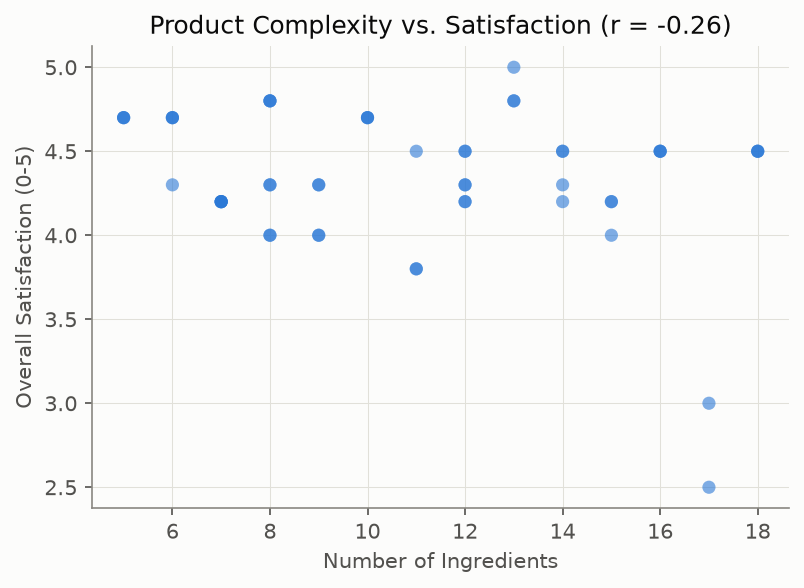

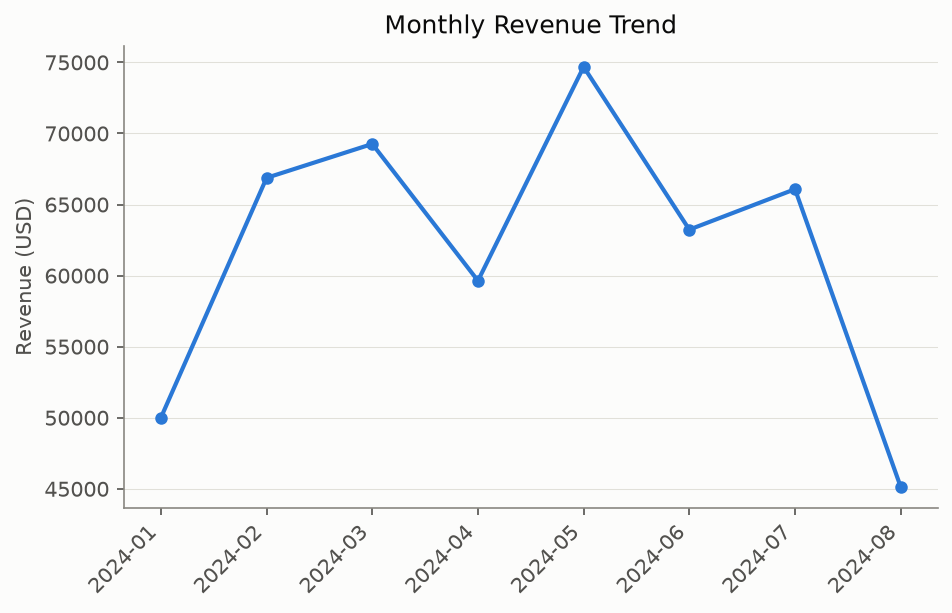

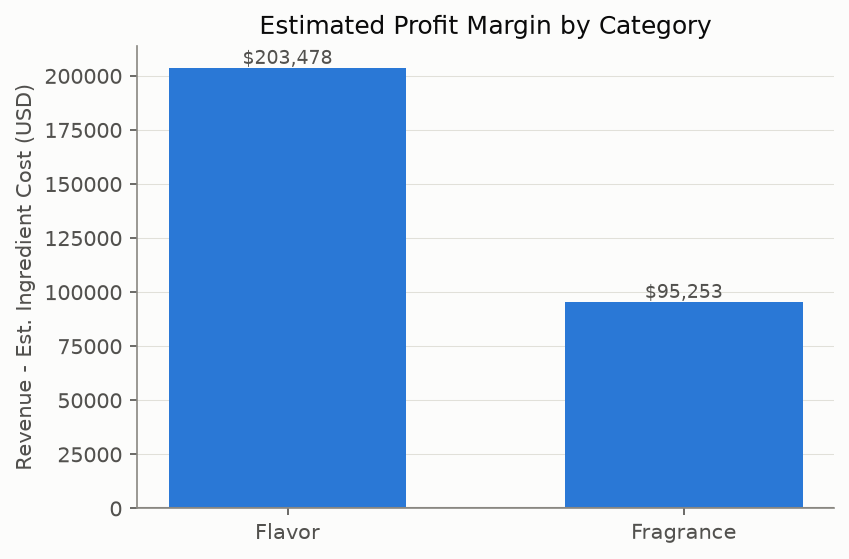

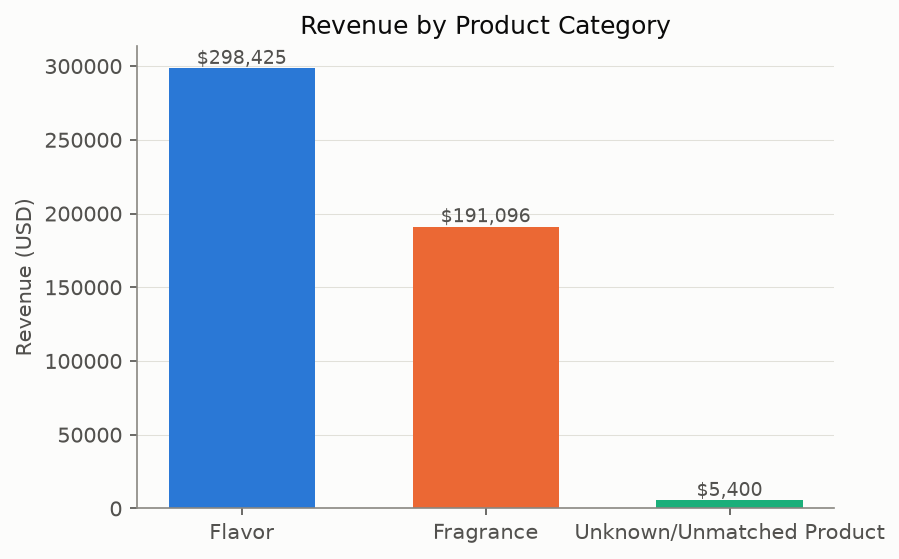

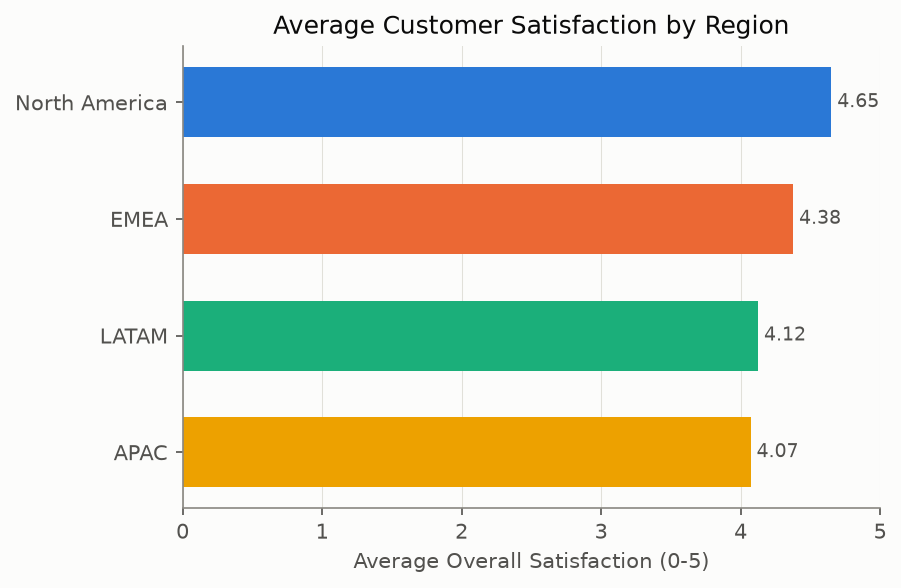

In [11]:
from src import visualize

viz_dir = PROJECT_ROOT / 'output' / 'visualizations'
visualize.generate_all(database_path=str(DB_PATH), output_dir=str(viz_dir))

for png in sorted(viz_dir.glob('*.png')):
    display(Image(filename=str(png)))

In [12]:
conn.close()